In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.transforms.functional as F
import matplotlib.pyplot as plt

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=False)

100%|██████████| 170M/170M [00:06<00:00, 24.5MB/s]


In [2]:
class EncoderDecoder(nn.Module):
    def __init__(self):
        super(EncoderDecoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.ConvTranspose2d(64, 3, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = EncoderDecoder().to(device)

In [3]:
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 15
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for i, data in enumerate(trainloader):
        color_imgs, _ = data
        gray_imgs = F.rgb_to_grayscale(color_imgs)

        color_imgs = color_imgs.to(device)
        gray_imgs = gray_imgs.to(device)

        optimizer.zero_grad()
        outputs = model(gray_imgs)
        loss = criterion(outputs, color_imgs)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], L1 Loss: {running_loss/len(trainloader):.4f}")

Epoch [1/15], L1 Loss: 0.1335
Epoch [2/15], L1 Loss: 0.1116
Epoch [3/15], L1 Loss: 0.1075
Epoch [4/15], L1 Loss: 0.1049
Epoch [5/15], L1 Loss: 0.1034
Epoch [6/15], L1 Loss: 0.1020
Epoch [7/15], L1 Loss: 0.1012
Epoch [8/15], L1 Loss: 0.1001
Epoch [9/15], L1 Loss: 0.0997
Epoch [10/15], L1 Loss: 0.0991
Epoch [11/15], L1 Loss: 0.0987
Epoch [12/15], L1 Loss: 0.0982
Epoch [13/15], L1 Loss: 0.0977
Epoch [14/15], L1 Loss: 0.0975
Epoch [15/15], L1 Loss: 0.0970


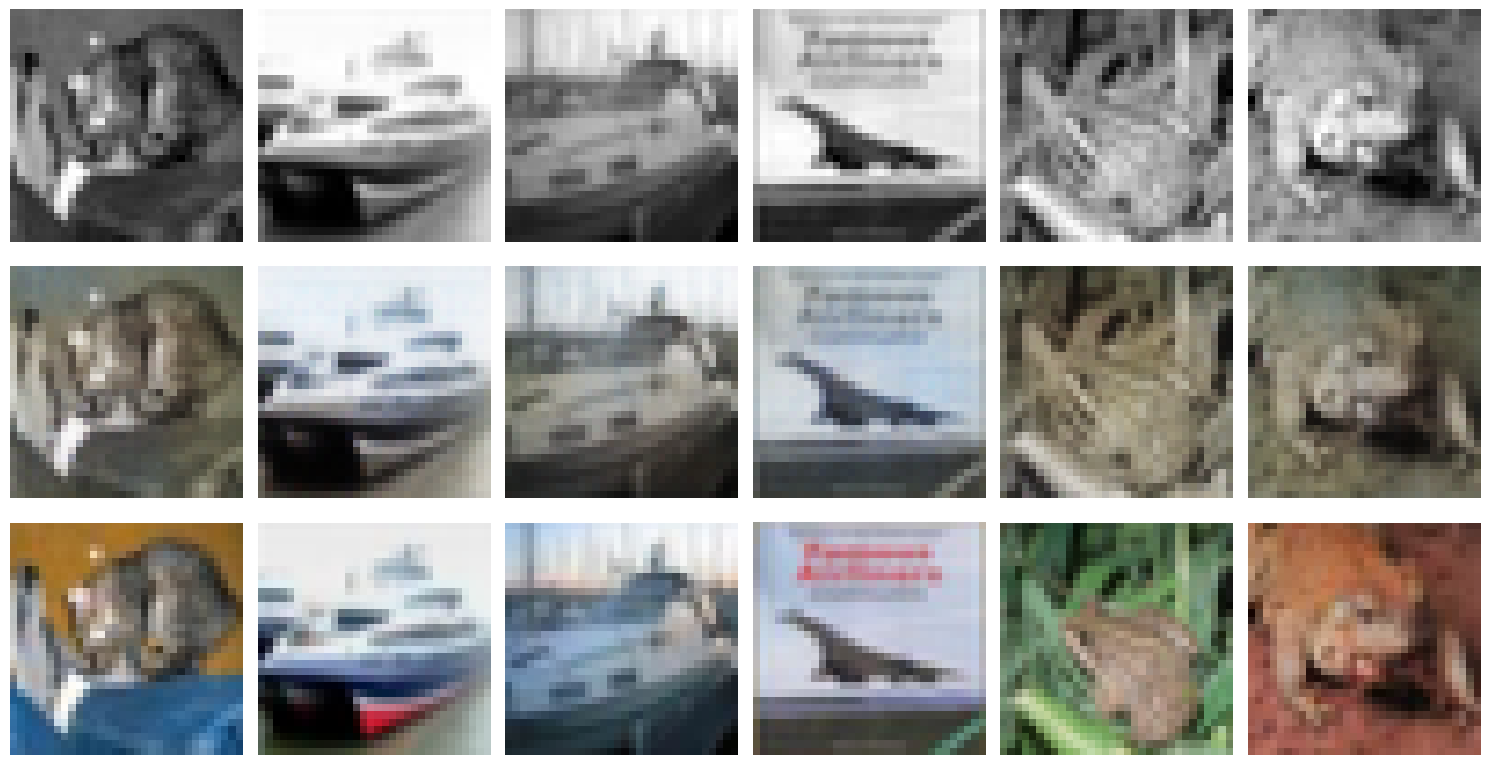

In [4]:
model.eval()
dataiter = iter(testloader)
color_imgs, _ = next(dataiter)
gray_imgs = F.rgb_to_grayscale(color_imgs)

color_imgs = color_imgs.to(device)
gray_imgs = gray_imgs.to(device)

with torch.no_grad():
    outputs = model(gray_imgs)

gray_imgs = gray_imgs.cpu()
outputs = outputs.cpu()
color_imgs = color_imgs.cpu()

fig, axes = plt.subplots(3, 6, figsize=(15, 8))
for i in range(6):
    axes[0, i].imshow(gray_imgs[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    out_img = outputs[i] * 0.5 + 0.5
    axes[1, i].imshow(out_img.permute(1, 2, 0).numpy())
    axes[1, i].axis('off')

    real_img = color_imgs[i] * 0.5 + 0.5
    axes[2, i].imshow(real_img.permute(1, 2, 0).numpy())
    axes[2, i].axis('off')

plt.tight_layout()
plt.show()